# Trabalho Fundamento em Ciência de Dados
## Tema: Análise do histórico e correlação do Bitcoin
### Alunos
- Predo Henrique Covisi; RA:
- Lucca Teodoro Vaz; RA: 18119311

### Instruções para Trabalho
1) Descrição do problema e dos dados
-  Apresentar o tema escolhido;
- Descrever a origem da base de dados;
- Explicar os objetivos ou perguntas que serão investigadas.
2) Preparação dos dados
- Identificar e tratar valores ausentes ou inconsistentes;
- Remover duplicidades, quando necessário;
- Descrever as etapas de limpeza e pré-processamento dos dados.
3) Análise exploratória dos dados
Realizar análises utilizando tabelas e gráficos para responder às perguntas propostas.
Exemplos:
- Distribuiçao das variáveis;
- Comparaçao entre grupos;
- Associaçoes entre variáveis;
- Identificação de padrões ou tendências.
Devem ser utilizados pelo menos três tipos diferentes de visualizaçao de dados, como his-
togramas, gráficos de barras, gráficos de disperssão, boxplots, entre outros.
4) Resultados e conclusões
- Apresentar os principais resultados encontrados;
- Discutir possíveis limitações da base de dados;
- Destacar conclusões e aplicações do estudo

## 1) Descrição do Problema e dos dado

#### 1a) Apresentar o tema escolhido:
O tema escolhido foi a análise do histórico e da correlação do Bitcoin com outros ativos financeiros. Assim, nosso objetivo é fazer uma análise profunda da cotação do Bitcoin e da sua correlação, que mudou ao longo dos anos, com outros ativos financeiros relevantes, como o Petróleo, Bolsas Americana e Brasileria, Ouro, Etherium ( segunda maior criptomoeda ), Titulos do Tesouro, entre outros. Escolhemos esse tema devido ao grande interesse que temos no mercado financeiro e na influência que o Bitcoin, e outras criptomoedas, vem ganhando com o passar do tempo.

#### 1b) Descrever a Origim da base de dados


#### 1c) Explicar os objetivos ou perguntas que serão investigadas
1) Fornecer uma breve contextualização sobre o Bitcoin
2) Fazer observações com relação ao preço do bictoin  ( como volatidade, drawdown entre outros )
3) Analisar a correlação do Bitcoin com outros ativos financeiros
4) Representar essa correlação de forma gráfica e matemática
5) Tentar realizar previsões relativas a cotação do Bitcoin com base em seu histórico e correlação com outros ativos financeiros

## 2) Preparação dos Dados

### 1) Importação e limpeza dos dados dos ativos financeiros

In [58]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [72]:
#Primeiro colocamos os tickers que serão importados em uma lista 
tickers_ativos = [
    "BTC-USD", #Bitcoin
    "ETH-USD", #Etherium
    "^GSPC", #S&P 500
    "^IXIC", #Nasdaq
    "^BVSP", #Bovespa
    "GC=F", #Ouro 
    "CL=F", #Petróleo
    "DX-Y.NYB", #Dólar
]

#Agora fazemos o donwload dos dados desses ativos tra
df_ativos = yf.download(tickers_ativos, start="2020-01-01")

#Filtrando apenas as 4 métricas desejadas
metricas_desejadas = ['Open', 'High', 'Low', 'Close']
df_filtrado = df_ativos[metricas_desejadas]

#Pega primeiro nível das colunas e coloca com índice nas linhas
df_formatado = df_filtrado.stack(level=0)

#Renomeando as colunas de índice para facilitar a leitura
df_formatado.index.names = ['Data', 'Métrica']

df_ativos = df_formatado
df_ativos.head(20)

[*********************100%***********************]  7 of 8 completed


Ticker                  BTC-USD       CL=F   DX-Y.NYB     ETH-USD  \
Data       Métrica                                                  
2020-01-01 Open     7194.892090        NaN        NaN  129.630661   
           High     7254.330566        NaN        NaN  132.835358   
           Low      7174.944336        NaN        NaN  129.198288   
           Close    7200.174316        NaN        NaN  130.802002   
2020-01-02 Open     7202.551270  61.599998  96.480003  130.820038   
           High     7212.155273  61.599998  96.870003  130.820038   
           Low      6935.270020  60.639999  96.430000  126.954910   
           Close    6985.470215  61.180000  96.849998  127.410179   
2020-01-03 Open     6984.428711  61.180000  96.790001  127.411263   
           High     7413.715332  64.089996  97.110001  134.554016   
           Low      6914.996094  61.130001  96.709999  126.490021   
           Close    7344.884277  63.049999  96.839996  134.171707   
2020-01-04 Open     7345.375488        NaN        NaN  134.168518   
           High     7427.385742        NaN        NaN  136.052719   
           Low      7309.514160        NaN        NaN  133.040558   
           Close    7410.656738        NaN        NaN  135.069366   
2020-01-05 Open     7410.451660        NaN        NaN  135.072098   
           High     7544.497070        NaN        NaN  139.410202   
           Low      7400.535645        NaN        NaN  135.045624   
           Close    7411.317383        NaN        NaN  136.276779   

Ticker                     GC=F     ^BVSP        ^GSPC        ^IXIC  
Data       Métrica                                                   
2020-01-01 Open             NaN       NaN          NaN          NaN  
           High             NaN       NaN          NaN          NaN  
           Low              NaN       NaN          NaN          NaN  
           Close            NaN       NaN          NaN          NaN  
2020-01-02 Open     1518.099976  115652.0  3244.669922  9039.459961  
           High     1528.699951  118573.0  3258.139893  9093.429688  
           Low      1518.000000  115649.0  3235.530029  9010.889648  
           Close    1524.500000  118573.0  3257.850098  9092.190430  
2020-01-03 Open     1530.099976  118564.0  3226.360107  8976.429688  
           High     1552.699951  118792.0  3246.149902  9065.759766  
           Low      1530.099976  117341.0  3222.340088  8976.429688  
           Close    1549.199951  117707.0  3234.850098  9020.769531  
2020-01-04 Open             NaN       NaN          NaN          NaN  
           High             NaN       NaN          NaN          NaN  
           Low              NaN       NaN          NaN          NaN  
           Close            NaN       NaN          NaN          NaN  
2020-01-05 Open             NaN       NaN          NaN          NaN  
           High             NaN       NaN          NaN          NaN  
           Low              NaN       NaN          NaN          NaN  
           Close            NaN       NaN          NaN          NaN

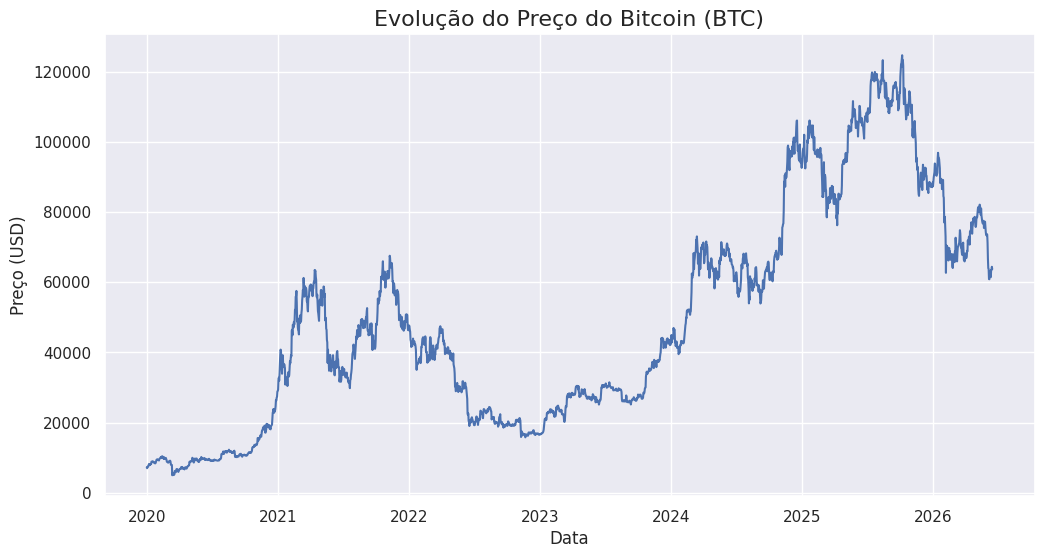

In [73]:
btc_close = df_criptomoedas.loc[(slice(None), 'Close'), 'BTC-USD'].reset_index()

sns.set_theme(style='darkgrid')
plt.figure(figsize=(12,6))

sns.lineplot(x='Data', y='BTC-USD', data=btc_close)

plt.title('Evolução do Preço do Bitcoin (BTC)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (USD)', fontsize=12)

plt.show()

### 2) Verificação de dados faltantes

In [75]:
# Verificação dos dados faltantes
dados = df_ativos
dados.isna().sum() #Conta número de dados faltantes e imprime os resultados

Ticker
BTC-USD        0
CL=F        2940
DX-Y.NYB    2940
ETH-USD        0
GC=F        2940
^BVSP       3012
^GSPC       2948
^IXIC       2948
dtype: int64

A partir dessa verificação apesentam-se vários dados faltantes, os quais ja eram esperados. Isso porque, diferetemente dos mercados tradicionais o bitcoin e o etherium são negociados de fim de semana e nos feriados. Assim, faltam dados dos fim de semanas de todos os ativos financeiros tradiconais 

Portanto, para analisar a correlação entre o bitcoin e outros ativos ( exceto o eth ), existem duas opções:
1) Adicionamos, artificialmente, os dados do fechamento do dia anterior para os dias com dados faltantes, para os ativos financeiros tradicionais
2) Ou Excluimos os dados de Bitcoin e do Etherium nos fim de semanas e feriados

Para deixar a análise de correlação a mais acertiva possível, optamos pela segunda opção. Mas antes disso, faremos algumas observaçẽos relativas ao bitcoin e sua correlação com Etherium ( para que dados não sejam perdidos )